In [1]:
import pandas as pd

# Import Class from data_pipeline.py
from src.data_pipeline import SalesDataPipeline 

if __name__ == "__main__":
    # Initialize Data Pipeline
    pipeline = SalesDataPipeline(train_path='data/sales.csv', test_path='data/sample_submission.csv')
    
    # Execute inspection and preprocessing steps
    pipeline.load_data()
    pipeline.inspect_and_fix_dates()
    pipeline.inspect_and_fix_anomalies()
    pipeline.prepare_master_data() 

    base_data = pipeline.create_time_features()
    
    # Preview results
    print("\n--- PREVIEW FIRST 5 ROWS ---")
    display(base_data.head())

2026-05-09 20:55:06,859 - INFO - [1/6] Loading datasets...
2026-05-09 20:55:06,868 - INFO - Datasets loaded successfully.
2026-05-09 20:55:06,869 - INFO - [3/6] Inspecting time-series continuity...
2026-05-09 20:55:06,871 - INFO - Time series is fully continuous.
2026-05-09 20:55:06,872 - INFO - [4/6] Inspecting anomalous data...
2026-05-09 20:55:06,873 - INFO - [5/6] Building master dataset...
2026-05-09 20:55:06,876 - INFO - [6/6] Creating time-series baseline features...
2026-05-09 20:55:06,883 - INFO - Feature engineering completed successfully.



--- PREVIEW FIRST 5 ROWS ---


,Date,Revenue,COGS,is_test,day_of_week,day_of_month,month,quarter,year,week_of_year,is_weekend,is_month_start,is_month_end,revenue_lag_1,revenue_lag_7,revenue_lag_30,rolling_mean_7,rolling_std_7,revenue_growth_rate
0,2012-07-04,5123547.94,3982991.19,0,2,4,7,3,2012,27,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,0,3,5,7,3,2012,27,0,0,0,5123547.94,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,3054029.42,2517632.84,0,4,6,7,3,2012,27,0,0,0,2751773.45,NaN,NaN,NaN,NaN,-0.462916
3,2012-07-07,2667930.94,2108246.62,0,5,7,7,3,2012,27,1,0,0,3054029.42,NaN,NaN,NaN,NaN,0.109840
4,2012-07-08,2360851.90,1808622.79,0,6,8,7,3,2012,27,1,0,0,2667930.94,NaN,NaN,NaN,NaN,-0.126423


In [2]:
# IMPORT CLASS 
from src.feature_engineer import FeatureEngineer 

# INITIALIZE FEATURE ENGINEERING 
engineer = FeatureEngineer(master_df=base_data, data_dir='data/')

# Chain feature engineering methods sequentially
final_data = (engineer
              .add_promotions()           # Step 1: Merge promotions data
              .add_web_traffic()          # Step 2: Merge web traffic data
              .add_inventory()            # Step 3: Merge inventory data
              .add_sales_lags()           # Step 4: Add sales lags (Renamed)
              .add_calendar_events()      # Step 5: Add calendar & payday events (Renamed)
              .add_proximity_features()   # Solution 2: Proximity features (waiting time)
              .add_momentum_features()    # Solution 3: Momentum and Acceleration
              .add_feature_interactions() # Solution 4: Advanced Cross-Interactions
              .get_data())

# Extract all numeric columns (Int, Float)
numeric_cols = final_data.select_dtypes(include=['number']).columns

# Fill missing values with 0 ONLY for these numeric columns
final_data[numeric_cols] = final_data[numeric_cols].fillna(0) 

display(final_data.head()) 

2026-05-09 20:55:06,905 - INFO - [1/8] Processing promotions dataset...
2026-05-09 20:55:06,921 - INFO - Promotion features added successfully.
2026-05-09 20:55:06,922 - INFO - [2/8] Processing web traffic dataset...
2026-05-09 20:55:06,933 - INFO - Traffic features added successfully.
2026-05-09 20:55:06,934 - INFO - [3/8] Processing inventory dataset...
2026-05-09 20:55:07,012 - INFO - Inventory features added successfully.
2026-05-09 20:55:07,013 - INFO - [4/8] Creating lag and rolling features...
2026-05-09 20:55:07,016 - INFO - Lag and rolling features created successfully.
2026-05-09 20:55:07,016 - INFO - [5/8] Creating calendar event features...
2026-05-09 20:55:07,018 - INFO - Calendar event features created successfully.
2026-05-09 20:55:07,019 - INFO - [6/8] Creating proximity features...
2026-05-09 20:55:07,043 - INFO - Proximity features created successfully.
2026-05-09 20:55:07,044 - INFO - [7/8] Creating momentum features...
2026-05-09 20:55:07,047 - INFO - Momentum featu

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,month,quarter,year,week_of_year,...,days_to_payday,days_to_double_day,revenue_lag_2,revenue_lag_3,revenue_diff_1,revenue_diff_7,revenue_acceleration,weekend_x_payday,promo_x_weekend,sessions_per_dayofweek
0,2012-07-04,5123547.94,3982991.19,0,2,4,7,3,2012,27,...,1,3,0.00,0.00,0.00,0.0,0.00,0,0,0.0
1,2012-07-05,2751773.45,2150580.23,0,3,5,7,3,2012,27,...,0,2,0.00,0.00,5123547.94,0.0,5123547.94,0,0,0.0
2,2012-07-06,3054029.42,2517632.84,0,4,6,7,3,2012,27,...,9,1,5123547.94,0.00,-2371774.49,0.0,-7495322.43,0,0,0.0
3,2012-07-07,2667930.94,2108246.62,0,5,7,7,3,2012,27,...,8,0,2751773.45,5123547.94,302255.97,0.0,2674030.46,0,0,0.0
4,2012-07-08,2360851.90,1808622.79,0,6,8,7,3,2012,27,...,7,30,3054029.42,2751773.45,-386098.48,0.0,-688354.45,0,0,0.0


In [3]:
# Export final dataset to CSV 
final_data.to_csv('data/final_data_ready.csv', index=False)

Revenue Skewness score is: 1.30


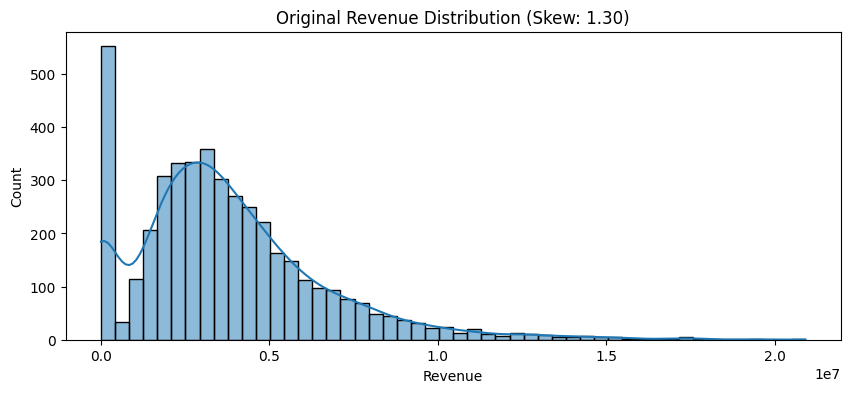

Highly right-skewed data! Applying Log Transform.
Skewness after transformation: -2.21 (Significantly smoother!)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========================================================
# MATHEMATICAL CHECK FOR SKEWNESS & TRANSFORMATION
# ========================================================
# 1. Mathematical Check
skew_score = final_data['Revenue'].skew()
print(f"Revenue Skewness score is: {skew_score:.2f}")

# 2. Visualization
plt.figure(figsize=(10, 4))
sns.histplot(final_data['Revenue'], bins=50, kde=True)
plt.title(f"Original Revenue Distribution (Skew: {skew_score:.2f})")
plt.show()

# 3. Decision Making 
if skew_score > 1:
    print("Highly right-skewed data! Applying Log Transform.")
    
    # Apply log1p transform (log(1+x)) to handle zero values safely
    final_data['Revenue_Log'] = np.log1p(final_data['Revenue'])
    
    # Print result after transformation
    new_skew = final_data['Revenue_Log'].skew()
    print(f"Skewness after transformation: {new_skew:.2f} (Significantly smoother!)")
    
    # Update target variable for model training 
    TARGET = 'Revenue_Log'
else:
    print("Data distribution is acceptable.")
    TARGET = 'Revenue' 

In [ ]:
# Import required pipelines
from src.model_benchmarker import ModelBenchmarker
from src.financial_forecaster import FinancialForecaster

# DECLARE SAFE FEATURES 
SAFE_FEATURES = [
    # Calendar & Event Features
    'day_of_week', 'day_of_month', 'month', 'year', 'is_weekend', 
    'is_promo_active', 'active_promos_count', 'is_payday', 'is_double_day', 'is_christmas',
    
    # Memory/Lag Features
    'sessions_lag_1', 'revenue_lag_1', 'revenue_lag_7', 'revenue_rolling_mean_7',
    
    # Proximity Features (Solution 2)
    'days_to_payday', 'days_to_double_day',
    
    # Momentum Features (Solution 3)
    'revenue_diff_1', 'revenue_diff_7', 'revenue_acceleration',
    
    # Interaction Features (Solution 4)
    'weekend_x_payday', 'promo_x_weekend', 'sessions_per_dayofweek'
] 

# Added new rolling columns here to prevent NaN issues
COLS_TO_FILL = [
    'sessions_lag_1', 
    'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_30', 
    'revenue_rolling_mean_7', 'revenue_rolling_mean_30', 'revenue_rolling_std_7',
    'total_stock_on_hand', 'total_stockouts'
] 

# Define the model arsenal
models_to_tune = ['LightGBM', 'XGBoost', 'CatBoost']
optimized_models = {} 

# ========================================================
# PHASE 1: FIND THE CHAMPION MODEL FOR REVENUE
# ========================================================
print("\n" + "="*50 + "\nARENA 1: TUNING MODELS FOR REVENUE")

benchmarker_rev = ModelBenchmarker(
    data=final_data, 
    features=SAFE_FEATURES, 
    target_col='Revenue_Log'
)
benchmarker_rev.prepare_data()

# Run hyperparameter tuning
for model in models_to_tune:
    benchmarker_rev.tune_with_optuna(model_name=model, n_trials=30) 

# Execute experiments and extract leaderboard
lb_rev = benchmarker_rev.run_experiments().show_leaderboard()

# Automatically fetch the Top 1 Model (Row 0, 'Model' column)
best_rev_name = lb_rev.iloc[0]['Model']
print(f"Revenue Champion: {best_rev_name}")

# Store the champion in our dictionary
optimized_models['Revenue'] = benchmarker_rev.models[best_rev_name]


# ========================================================
# PHASE 2: FIND THE CHAMPION MODEL FOR COGS
# ========================================================
print("\n" + "="*50 + "\nARENA 2: TUNING MODELS FOR COGS")

final_data['COGS_Log'] = np.log1p(final_data['COGS'])

benchmarker_cogs = ModelBenchmarker(
    data=final_data, 
    features=SAFE_FEATURES, 
    target_col='COGS_Log'
)
benchmarker_cogs.prepare_data()

# Run hyperparameter tuning
for model in models_to_tune:
    benchmarker_cogs.tune_with_optuna(model_name=model, n_trials=15)s

# Execute experiments and extract leaderboard
lb_cogs = benchmarker_cogs.run_experiments().show_leaderboard()

# Automatically fetch the Top 1 Model for COGS
best_cogs_name = lb_cogs.iloc[0]['Model']
print(f"COGS Champion: {best_cogs_name}")

# Store the champion in our dictionary
optimized_models['COGS'] = benchmarker_cogs.models[best_cogs_name]


# ========================================================
# PHASE 3: DUAL FORECASTING WITH THE CHAMPIONS
# ========================================================
print("\n" + "="*50 + "\n[PHASE 4] GENERATING FINAL SUBMISSION")

# Initialize the final forecaster with our optimized models
forecaster = FinancialForecaster(
    data=final_data, 
    features=SAFE_FEATURES,
    targets=['Revenue_Log', 'COGS_Log'], 
    custom_models=optimized_models # Inject the champions here!
)

# Run the final pipeline and export the submission file
submission = (forecaster
              .prepare_data()
              .train_and_predict()
              .generate_report(export_path='submission.csv')) 

2026-05-09 20:55:08,534 - INFO - [1/4] Preparing time-series datasets...
2026-05-09 20:55:08,540 - INFO - Train size: 3649 rows
2026-05-09 20:55:08,540 - INFO - Validation size: 184 rows
2026-05-09 20:55:08,541 - INFO - [2/4] Starting Optuna tuning for LightGBM...



ARENA 1: TUNING MODELS FOR REVENUE


  0%|          | 0/30 [00:00<?, ?it/s]

2026-05-09 20:55:43,911 - INFO - Best tuned model added: LightGBM_Optuna_Tuned
2026-05-09 20:55:43,912 - INFO - [2/4] Starting Optuna tuning for XGBoost...


  0%|          | 0/30 [00:00<?, ?it/s]

2026-05-09 20:56:33,188 - INFO - Best tuned model added: XGBoost_Optuna_Tuned
2026-05-09 20:56:33,189 - INFO - [2/4] Starting Optuna tuning for CatBoost...


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-05-09 21:03:12,596] Trial 14 failed with parameters: {'iterations': 834, 'learning_rate': 0.022850686124661398, 'depth': 6, 'subsample': 0.9252639323122223} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\Users\trann\AppData\Local\Programs\Python\Python313\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "c:\Project_2\src\model_benchmarker.py", line 406, in objective
    model.fit(
    ~~~~~~~~~^
        X_tr_cat,
        ^^^^^^^^^
    ...<8 lines>...
        verbose=False
        ^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\trann\AppData\Local\Programs\Python\Python313\Lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 


[PHASE 5] BUSINESS INSIGHTS & EXPLAINABILITY

Generating SHAP Insights for REVENUE Model: XGBoost_Optuna_Tuned...


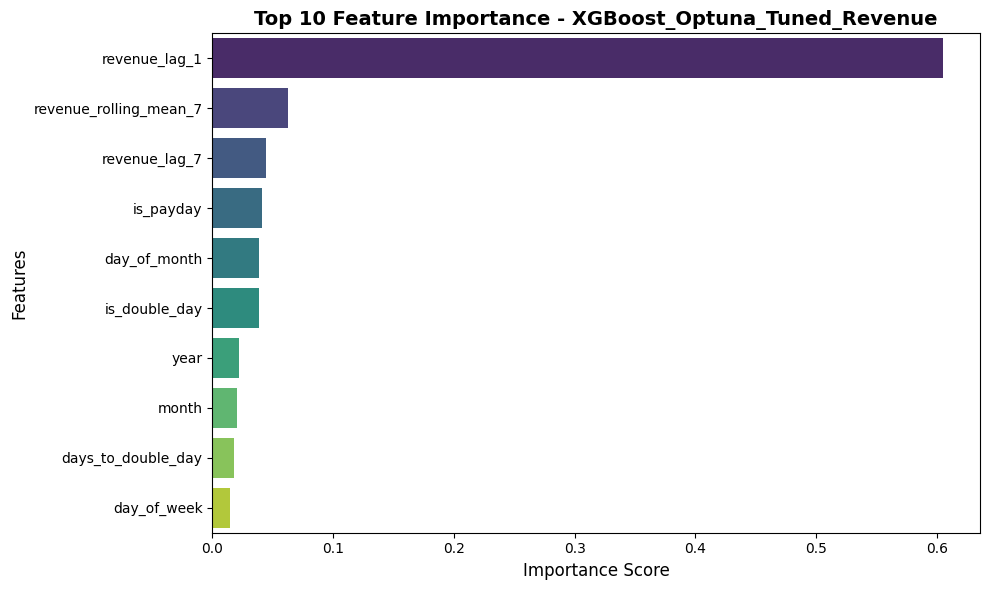

Feature Importance plot saved successfully at: assets/XGBoost_Optuna_Tuned_Revenue_feature_importance.png


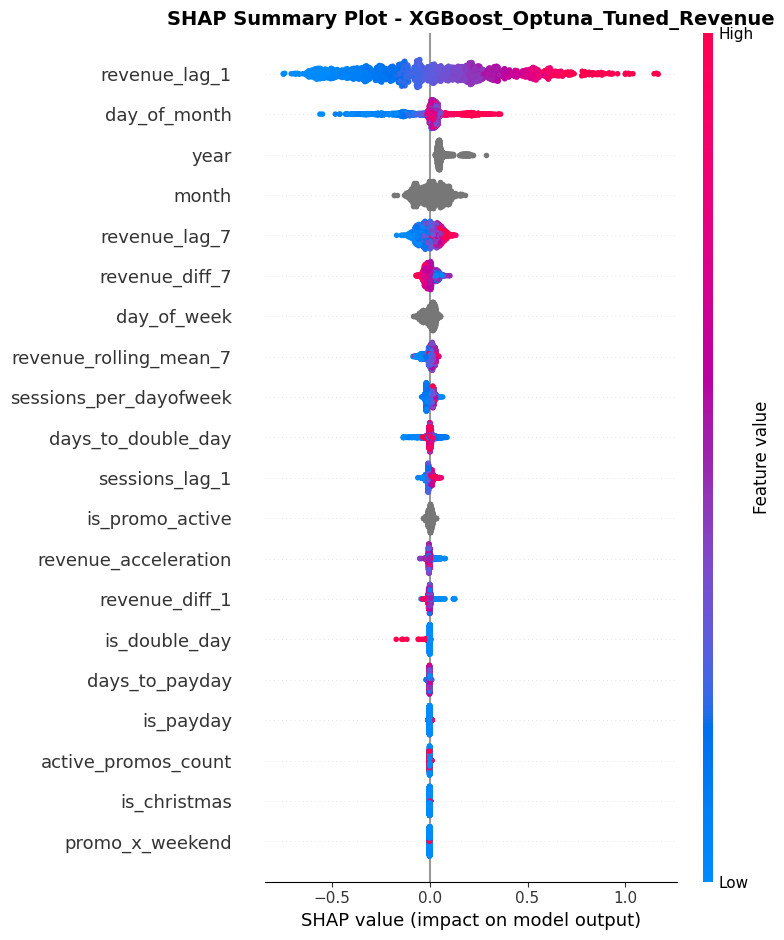

SHAP Summary plot saved successfully at: assets/XGBoost_Optuna_Tuned_Revenue_shap_summary.png

Generating SHAP Insights for COGS Model: LightGBM...


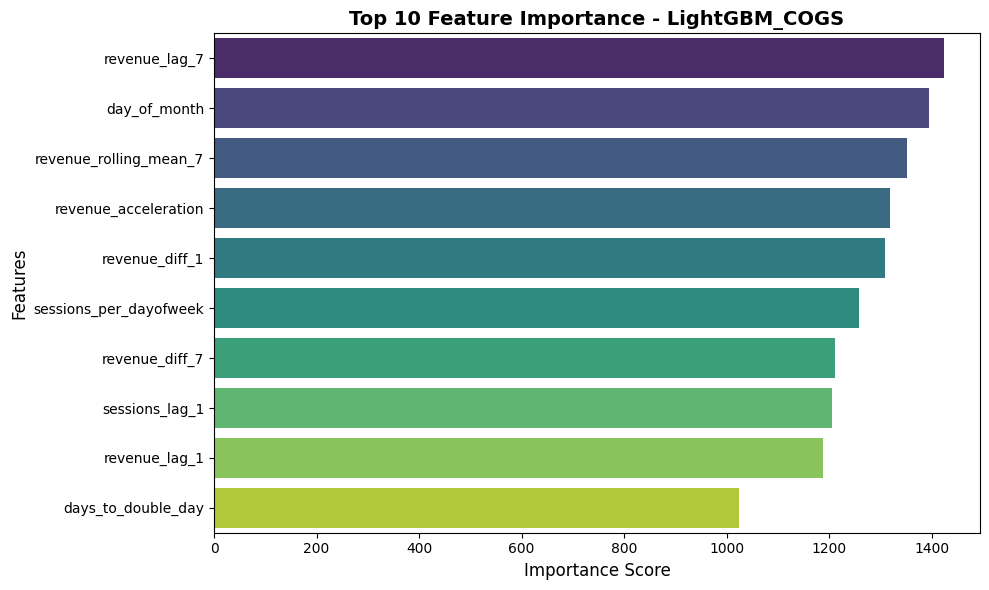

Feature Importance plot saved successfully at: assets/LightGBM_COGS_feature_importance.png


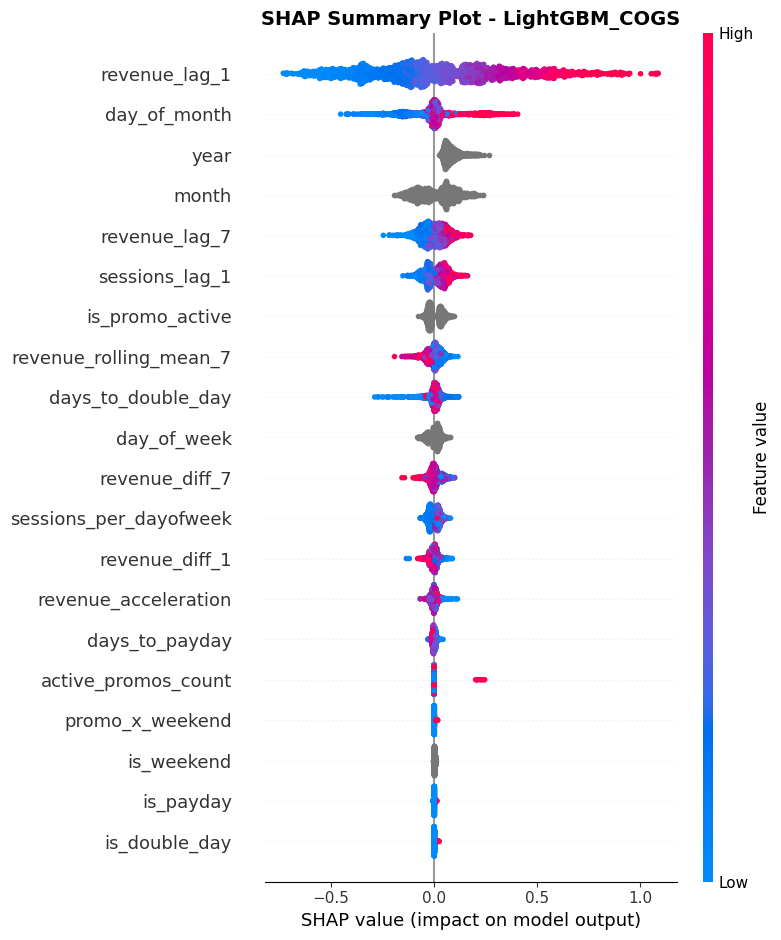

SHAP Summary plot saved successfully at: assets/LightGBM_COGS_shap_summary.png

All explainability reports have been successfully generated and saved to the 'assets/' folder!


In [ ]:
# Import the explainer class from the src folder
from src.explainability import ModelExplainer  

print("\n" + "="*50)
print("[PHASE 5] BUSINESS INSIGHTS & EXPLAINABILITY")
print("="*50)

# ======================================================================
# 1. EXPLAIN THE REVENUE CHAMPION (XGBoost)
# ======================================================================
rev_model_name = best_rev_name 
rev_model = optimized_models['Revenue']

print(f"\nGenerating SHAP Insights for REVENUE Model: {rev_model_name}...")

# Sample 2000 rows from the training data for speed
X_explain_rev = benchmarker_rev.X_train.sample(
    n=min(2000, len(benchmarker_rev.X_train)), 
    random_state=42
).copy()

# Initialize explainer for Revenue
explainer_rev = ModelExplainer(
    model=rev_model, 
    X_data=X_explain_rev, 
    model_name=f"{rev_model_name}_Revenue", 
    output_dir="assets/" 
)

# Generate plots
explainer_rev.plot_feature_importance(top_n=10)
explainer_rev.plot_shap_summary()


# ======================================================================
# 2. EXPLAIN THE COGS CHAMPION (LightGBM)
# ======================================================================
cogs_model_name = best_cogs_name 
cogs_model = optimized_models['COGS']

print(f"\nGenerating SHAP Insights for COGS Model: {cogs_model_name}...")

# Sample 2000 rows from the training data for speed
X_explain_cogs = benchmarker_cogs.X_train.sample(
    n=min(2000, len(benchmarker_cogs.X_train)), 
    random_state=42
).copy()

# Initialize explainer for COGS
explainer_cogs = ModelExplainer(
    model=cogs_model, 
    X_data=X_explain_cogs, 
    model_name=f"{cogs_model_name}_COGS", 
    output_dir="assets/" 
)

# Generate plots
explainer_cogs.plot_feature_importance(top_n=10)
explainer_cogs.plot_shap_summary()

print("\nAll explainability reports have been successfully generated and saved to the 'assets/' folder!") 